# Template API Notebook

This is a template notebook. The first heading should be the title of what notebook is about. For example, if it is a neo4j tutorial the heading should be `Neo4j API`.

- Add description of what the notebook does.
- Point to references, e.g. (neo4j.API.md)
- Add citations.
- Keep the notebook flow clear.
- Comments should be imperative and have a period at the end.
- Your code should be well commented. 

The name of this notebook should in the following format:
- if the notebook is exploring `pycaret API`, then it is `pycaret.API.ipynb`

Follow the reference to write notebooks in a clear manner: https://github.com/causify-ai/helpers/blob/master/docs/coding/all.jupyter_notebook.how_to_guide.md

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

## Imports

In [5]:
import logging
!pip install snowflake-connector-python requests pandas matplotlib plotly python-dotenv

#import helpers.hdbg as hdbg
#import helpers.hprint as hprint

## Configuration

In [ ]:
hdbg.init_logger(verbosity=logging.INFO)

_LOG = logging.getLogger(__name__)

hprint.config_notebook()

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()  # Load from .env in the current directory

# Check if values were loaded
print("User:", os.getenv("SNOWFLAKE_USER"))
print("Account:", os.getenv("SNOWFLAKE_ACCOUNT"))


User: PWADHWA
Account: RQSQUOH-VVC78987


## Make the notebook flow clear
Each notebook needs to follow a clear and logical flow, e.g:
- Load data
- Compute stats
- Clean data
- Compute stats
- Do analysis
- Show results

In [1]:
import os
import logging
from datetime import datetime
import requests
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import snowflake.connector
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [2]:
print("User:", os.getenv("SNOWFLAKE_USER"))
print("Password:", os.getenv("SNOWFLAKE_PASSWORD"))
print("Account:", os.getenv("SNOWFLAKE_ACCOUNT"))
print("Warehouse:", os.getenv("SNOWFLAKE_WAREHOUSE"))
print("Database:", os.getenv("SNOWFLAKE_DATABASE"))
print("Schema:", os.getenv("SNOWFLAKE_SCHEMA"))


User: PWADHWA
Password: Palakwadhwa@202003
Account: RQSQUOH-VVC78987
Warehouse: COMPUTE_WH
Database: BITCOIN_DB
Schema: PUBLIC


In [4]:
def connect_to_snowflake():
    """
    Connect to Snowflake using credentials from .env file.
    """
    conn = snowflake.connector.connect(
        user=os.getenv("SNOWFLAKE_USER"),
        password=os.getenv("SNOWFLAKE_PASSWORD"),
        account=os.getenv("SNOWFLAKE_ACCOUNT"),
        warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
        database=os.getenv("SNOWFLAKE_DATABASE"),
        schema=os.getenv("SNOWFLAKE_SCHEMA")
    )
    logger.info("✅ Connected to Snowflake")
    return conn

# Connect
conn = connect_to_snowflake()


INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 2.7.4, Python Version: 3.6.4, Platform: Windows-10-10.0.26100-SP0
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.
INFO:snowflake.connector.connection:Setting use_openssl_only mode to False
INFO:__main__:✅ Connected to Snowflake


In [7]:
conn.cursor().execute("USE DATABASE BITCOIN_DB")
conn.cursor().execute("USE SCHEMA PUBLIC")



INFO:snowflake.connector.cursor:query: [USE DATABASE BITCOIN_DB]
INFO:snowflake.connector.cursor:query execution done
INFO:snowflake.connector.cursor:query: [USE SCHEMA PUBLIC]
INFO:snowflake.connector.cursor:query execution done


In [8]:
def create_btc_table(conn):
    create_stmt = """
    CREATE TABLE IF NOT EXISTS BTC_PRICES (
        timestamp TIMESTAMP,
        price_usd FLOAT
    );
    """
    conn.cursor().execute(create_stmt)
    logger.info("✅ Table BTC_PRICES is ready.")

# Call the function
create_btc_table(conn)


INFO:snowflake.connector.cursor:query: [CREATE TABLE IF NOT EXISTS BTC_PRICES ( timestamp TIMESTAMP, price_usd FLOAT );]
INFO:snowflake.connector.cursor:query execution done
INFO:__main__:✅ Table BTC_PRICES is ready.


In [9]:
import requests

def fetch_bitcoin_price():
    """
    Fetch the latest Bitcoin price in USD from CoinGecko API.
    """
    url = "https://api.coingecko.com/api/v3/simple/price"
    params = {"ids": "bitcoin", "vs_currencies": "usd"}
    response = requests.get(url, params=params)
    response.raise_for_status()
    price = response.json()["bitcoin"]["usd"]
    logger.info(f"💰 Current Bitcoin Price: ${price}")
    return price

# Fetch and print
btc_price = fetch_bitcoin_price()
print("Fetched price:", btc_price)


INFO:__main__:💰 Current Bitcoin Price: $93784


Fetched price: 93784


NameError: name 'get_bitcoin_price' is not defined

In [15]:
from datetime import datetime

def insert_bitcoin_price(conn, price_usd):
    """
    Insert the current timestamp and Bitcoin price into the Snowflake table.
    """
    insert_stmt = """
    INSERT INTO BTC_PRICES (timestamp, price_usd)
    VALUES (%s, %s);
    """
    conn.cursor().execute(insert_stmt, (datetime.utcnow(), price_usd))
    logger.info("📥 Inserted Bitcoin price into Snowflake.")

# Insert latest price
insert_bitcoin_price(conn, btc_price)


INFO:snowflake.connector.cursor:query: [INSERT INTO BTC_PRICES (timestamp, price_usd) VALUES ('2025-05-06 13:24:33.29038...]
INFO:snowflake.connector.cursor:query execution done
INFO:__main__:📥 Inserted Bitcoin price into Snowflake.


In [26]:
import time
import matplotlib.pyplot as plt

# Loop to collect 5 prices at 10-second intervals
for i in range(5):
    btc_price = fetch_bitcoin_price()  # Fetch live price
    insert_bitcoin_price(conn, btc_price)  # Insert into Snowflake
    print(f"[{i+1}] Inserted price: {btc_price}")
    time.sleep(10)  # Wait 10 seconds between each

# Fetch data back from Snowflake
btc_df = fetch_btc_data(conn)

# Display last few rows
print(btc_df)




INFO:__main__:💰 Current Bitcoin Price: $93917
INFO:snowflake.connector.cursor:query: [INSERT INTO BTC_PRICES (timestamp, price_usd) VALUES ('2025-05-06 14:10:17.50731...]
INFO:snowflake.connector.cursor:query execution done
INFO:__main__:📥 Inserted Bitcoin price into Snowflake.


[1] Inserted price: 93917


INFO:__main__:💰 Current Bitcoin Price: $93917
INFO:snowflake.connector.cursor:query: [INSERT INTO BTC_PRICES (timestamp, price_usd) VALUES ('2025-05-06 14:10:28.23573...]
INFO:snowflake.connector.cursor:query execution done
INFO:__main__:📥 Inserted Bitcoin price into Snowflake.


[2] Inserted price: 93917


INFO:__main__:💰 Current Bitcoin Price: $93917
INFO:snowflake.connector.cursor:query: [INSERT INTO BTC_PRICES (timestamp, price_usd) VALUES ('2025-05-06 14:10:39.04460...]
INFO:snowflake.connector.cursor:query execution done
INFO:__main__:📥 Inserted Bitcoin price into Snowflake.


...

[4] Inserted price: 93935


INFO:__main__:💰 Current Bitcoin Price: $93935
INFO:snowflake.connector.cursor:query: [INSERT INTO BTC_PRICES (timestamp, price_usd) VALUES ('2025-05-06 14:11:00.81372...]
INFO:snowflake.connector.cursor:query execution done
INFO:__main__:📥 Inserted Bitcoin price into Snowflake.


[5] Inserted price: 93935


INFO:snowflake.connector.cursor:query: [SELECT * FROM BTC_PRICES ORDER BY timestamp ASC;]
INFO:snowflake.connector.cursor:query execution done


                    TIMESTAMP  PRICE_USD
0  2025-05-06 13:13:41.253096    93784.0
1  2025-05-06 13:24:33.290388    93784.0
2  2025-05-06 13:25:58.125975    93788.0
3  2025-05-06 13:26:08.742683    93788.0
4  2025-05-06 13:26:19.517189    93788.0
5  2025-05-06 13:26:30.297019    93788.0
6  2025-05-06 13:26:40.984126    93788.0
7  2025-05-06 14:06:16.844244    93843.0
8  2025-05-06 14:06:30.734054    93843.0
9  2025-05-06 14:06:41.544950    93880.0
10 2025-05-06 14:06:52.580573    93880.0
11 2025-05-06 14:07:03.494363    93880.0
12 2025-05-06 14:07:42.548931    93909.0
13 2025-05-06 14:07:53.360365    93909.0
14 2025-05-06 14:08:04.069229    93909.0
15 2025-05-06 14:08:14.892224    93909.0
16 2025-05-06 14:08:25.778342    93909.0
17 2025-05-06 14:10:17.507311    93917.0
18 2025-05-06 14:10:28.235739    93917.0
19 2025-05-06 14:10:39.044601    93917.0
20 2025-05-06 14:10:50.030948    93935.0
21 2025-05-06 14:11:00.813729    93935.0


                    TIMESTAMP  PRICE_USD         SMA_3  Volatility
0  2025-05-06 13:13:41.253096    93784.0           NaN         NaN
1  2025-05-06 13:24:33.290388    93784.0           NaN         NaN
2  2025-05-06 13:25:58.125975    93788.0  93785.333333    2.309401
3  2025-05-06 13:26:08.742683    93788.0  93786.666667    2.309401
4  2025-05-06 13:26:19.517189    93788.0  93788.000000    0.000000
5  2025-05-06 13:26:30.297019    93788.0  93788.000000    0.000000
6  2025-05-06 13:26:40.984126    93788.0  93788.000000    0.000000
7  2025-05-06 14:06:16.844244    93843.0  93806.333333   31.754265
8  2025-05-06 14:06:30.734054    93843.0  93824.666667   31.754265
9  2025-05-06 14:06:41.544950    93880.0  93855.333333   21.361960
10 2025-05-06 14:06:52.580573    93880.0  93867.666667   21.361960
11 2025-05-06 14:07:03.494363    93880.0  93880.000000    0.000073
12 2025-05-06 14:07:42.548931    93909.0  93889.666667   16.743158
13 2025-05-06 14:07:53.360365    93909.0  93899.333333   16.74

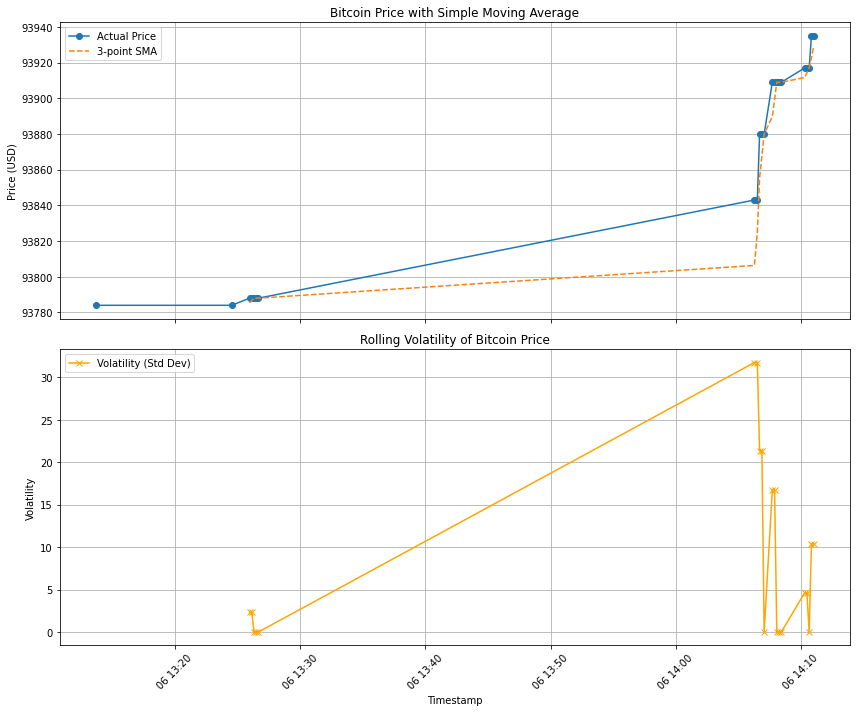

In [29]:
# Calculate a 3-point Simple Moving Average
btc_df['SMA_3'] = btc_df['PRICE_USD'].rolling(window=3).mean()

# Calculate rolling standard deviation (volatility)
btc_df['Volatility'] = btc_df['PRICE_USD'].rolling(window=3).std()

# Show latest entries with indicators
print(btc_df)

import matplotlib.pyplot as plt

# Ensure latest metrics are visible
btc_df['SMA_3'] = btc_df['PRICE_USD'].rolling(window=3).mean()
btc_df['Volatility'] = btc_df['PRICE_USD'].rolling(window=3).std()

# Set up subplots for price + volatility
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Price + SMA
axs[0].plot(btc_df['TIMESTAMP'], btc_df['PRICE_USD'], label='Actual Price', marker='o')
axs[0].plot(btc_df['TIMESTAMP'], btc_df['SMA_3'], label='3-point SMA', linestyle='--')
axs[0].set_title("Bitcoin Price with Simple Moving Average")
axs[0].set_ylabel("Price (USD)")
axs[0].legend()
axs[0].grid(True)

# Plot 2: Volatility
axs[1].plot(btc_df['TIMESTAMP'], btc_df['Volatility'], label='Volatility (Std Dev)', color='orange', marker='x')
axs[1].set_title("Rolling Volatility of Bitcoin Price")
axs[1].set_xlabel("Timestamp")
axs[1].set_ylabel("Volatility")
axs[1].legend()
axs[1].grid(True)

# Format x-axis
plt.xticks(rotation=45)
plt.tight_layout()

# Save the combined plot as PNG
plt.savefig("bitcoin_price_analysis.png", dpi=300)
plt.show()


In [30]:
btc_df['Moving_Avg'] = btc_df['PRICE_USD'].rolling(window=3).mean()
btc_df['Price_Change'] = btc_df['PRICE_USD'].diff()



In [10]:
class Template:
    """
    Brief imperative description of what the class does in one line, if needed.
    """
    def __init__(self):
        pass
    
    def method1(self, arg1:int) -> None:
        """
        Brief imperative description of what the method does in one line.

        You can elaborate more in the method docstring in this section, for e.g. explaining 
        the formula/algorithm. Every method/function should have a docstring, typehints and include the
        parameters and return as follows:

        :param arg1: description of arg1
        :return: description of return
        """
        # Code bloks go here.
        # Make sure to include comments to explain what the code is doing.
        # No empty lines between code blocks.
        pass


def template_function(arg1:int) -> None:
    """
    Brief imperative description of what the function does in one line.

    You can elaborate more in the function docstring in this section, for e.g. explaining 
    the formula/algorithm. Every function should have a docstring, typehints and include the
    parameters and return as follows:

    :param arg1: description of arg1
    :return: description of return
    """
    # Code bloks go here.
    # Make sure to include comments to explain what the code is doing.
    # No empty lines between code blocks.
    pass


## The flow should be highlighted using headings in markdown
```
# Level 1
## Level 2
### Level 3
```